<h1>Train — EfficientNet-B0</h1>

Trains and evaluates EfficientNet-B0 using the tuned hyperparameters from `ARCH_HYPERPARAMS["efficientnet_b0"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Atlantis
Train-time augmentation: on
Classes found (3): ['Dysfunctional', 'Functional', 'Suboptimal']
Train: 1310 | Val: 320 | Test: 113


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["efficientnet_b0"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"EfficientNet-B0: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

EfficientNet-B0: micro batch = 16, accumulation steps = 6 (effective batch size ≈ 96, tuned value = 96)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with EfficientNet-B0)
# ---------------------------------------------------------
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# EfficientNet's classifier is nn.Sequential(Dropout, Linear) — swap out
# just the Linear layer for our (optionally deeper) classifier head, same
# as the fc/classifier swaps used for the other architectures.
in_f = model.classifier[1].in_features
model.classifier[1] = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[EfficientNet-B0] Using gradient accumulation: 6 micro-batches per optimizer step (effective batch size ≈ micro_batch x 6).


[EfficientNet-B0] Epoch   1/100 | LR: 1.38e-03 | train loss 1.0914 acc 0.476 | val loss 0.8045 acc 0.578 *


[EfficientNet-B0] Epoch   2/100 | LR: 1.38e-03 | train loss 0.8261 acc 0.702 | val loss 0.9470 acc 0.575


[EfficientNet-B0] Epoch   3/100 | LR: 1.38e-03 | train loss 0.7406 acc 0.685 | val loss 0.4299 acc 0.828 *


[EfficientNet-B0] Epoch   4/100 | LR: 1.38e-03 | train loss 0.7523 acc 0.727 | val loss 0.6013 acc 0.691


...

[EfficientNet-B0] Epoch   9/100 | LR: 1.38e-03 | train loss 0.6132 acc 0.775 | val loss 0.5014 acc 0.812


[EfficientNet-B0] Epoch  10/100 | LR: 1.38e-03 | train loss 0.5781 acc 0.793 | val loss 0.7161 acc 0.684


[EfficientNet-B0] Epoch  11/100 | LR: 1.38e-03 | train loss 0.5693 acc 0.769 | val loss 0.4745 acc 0.797


[EfficientNet-B0] Epoch  12/100 | LR: 1.38e-03 | train loss 0.5488 acc 0.794 | val loss 0.4535 acc 0.825


[EfficientNet-B0] Epoch  13/100 | LR: 1.38e-03 | train loss 0.6095 acc 0.779 | val loss 0.6056 acc 0.781

[EfficientNet-B0] No val loss improvement for 10 epochs — stopping early at epoch 13.

[EfficientNet-B0] Restored best checkpoint (val loss = 0.4299)


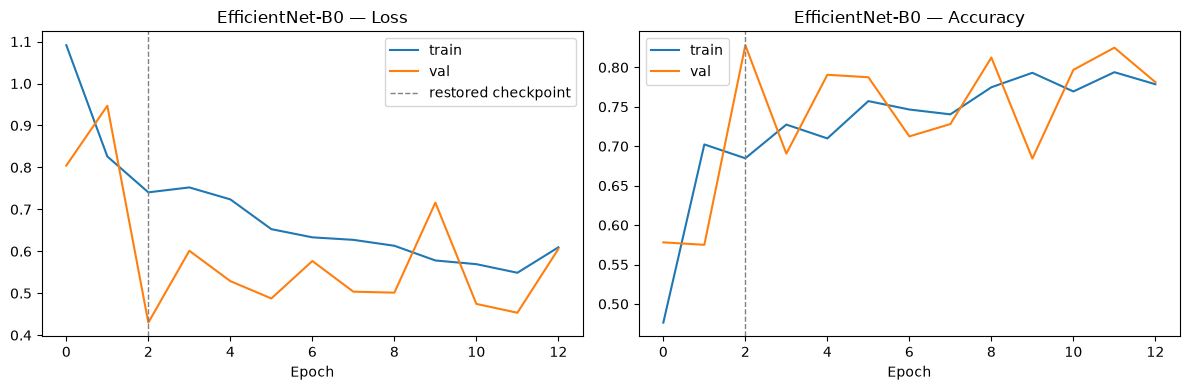

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "EfficientNet-B0", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "EfficientNet-B0")

## Evaluate on the test set

[EfficientNet-B0] Test accuracy: 0.708


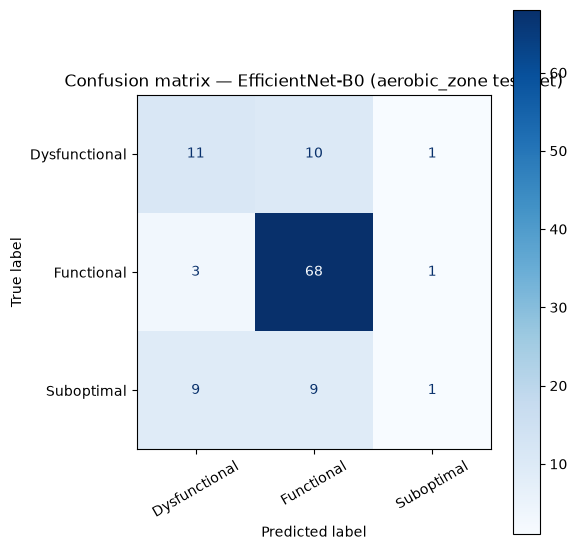

               precision    recall  f1-score   support

Dysfunctional      0.478     0.500     0.489        22
   Functional      0.782     0.944     0.855        72
   Suboptimal      0.333     0.053     0.091        19

     accuracy                          0.708       113
    macro avg      0.531     0.499     0.478       113
 weighted avg      0.647     0.708     0.655       113



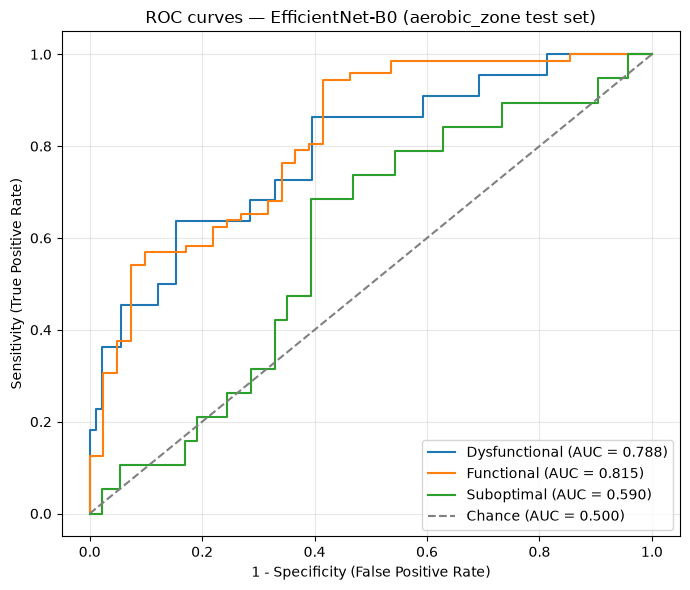

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.788
  Functional     : 0.815
  Suboptimal     : 0.590

Mean AUC (over 3/3 classes with test examples): 0.731


(np.float64(0.7079646017699115),
 {'Dysfunctional': 0.7877122877122877,
  'Functional': 0.8150406504065041,
  'Suboptimal': 0.5901455767077268})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "EfficientNet-B0", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("EfficientNet-B0", "efficientnet_b0")

Saved results to ../results/aerobic_zone_aug/results_aerobic_zone_efficientnet_b0_Atlantis.pkl


Saved model weights to ../models/aerobic_zone_efficientnet_b0_cnn.pt
